In [29]:

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

In [2]:
df= pd.read_csv('census-income .csv')
df

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  annual_income   32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [4]:
df['annual_income'].value_counts()

annual_income
<=50K    24720
>50K      7841
Name: count, dtype: int64

In [5]:
for i in df.columns:
    print(df[i].value_counts())
    print("_______________________________")
    

age
36    898
31    888
34    886
23    877
35    876
     ... 
83      6
88      3
85      3
86      1
87      1
Name: count, Length: 73, dtype: int64
_______________________________
workclass
Private             22696
Self-emp-not-inc     2541
Local-gov            2093
?                    1836
State-gov            1298
Self-emp-inc         1116
Federal-gov           960
Without-pay            14
Never-worked            7
Name: count, dtype: int64
_______________________________
fnlwgt
123011    13
164190    13
203488    13
121124    12
126675    12
          ..
316185     1
292353     1
205019     1
180296     1
422249     1
Name: count, Length: 21648, dtype: int64
_______________________________
education
HS-grad         10501
Some-college     7291
Bachelors        5355
Masters          1723
Assoc-voc        1382
11th             1175
Assoc-acdm       1067
10th              933
7th-8th           646
Prof-school       576
9th               514
12th              433
Doctorate        

In [6]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education-num     0
marital-status    0
occupation        0
relationship      0
race              0
sex               0
capital-gain      0
capital-loss      0
hours-per-week    0
native-country    0
annual_income     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(24)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
cat_cols= df.select_dtypes(include= "object").columns.tolist()
cat_cols

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country',
 'annual_income']

In [10]:
from sklearn.preprocessing import LabelEncoder
l= LabelEncoder()
for i in cat_cols:
    df[i]= l.fit_transform(df[i])

df
    

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39,0
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39,0
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39,0
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39,0
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,4,0,0,0,38,39,0
32557,40,4,154374,11,9,2,7,0,4,1,0,0,40,39,1
32558,58,4,151910,11,9,6,1,4,4,0,0,0,40,39,0
32559,22,4,201490,11,9,4,1,3,4,1,0,0,20,39,0


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       32537 non-null  int64
 2   fnlwgt          32537 non-null  int64
 3   education       32537 non-null  int64
 4   education-num   32537 non-null  int64
 5   marital-status  32537 non-null  int64
 6   occupation      32537 non-null  int64
 7   relationship    32537 non-null  int64
 8   race            32537 non-null  int64
 9   sex             32537 non-null  int64
 10  capital-gain    32537 non-null  int64
 11  capital-loss    32537 non-null  int64
 12  hours-per-week  32537 non-null  int64
 13  native-country  32537 non-null  int64
 14  annual_income   32537 non-null  int64
dtypes: int64(15)
memory usage: 4.0 MB


# Visualizations

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

In [13]:
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'petroff10', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


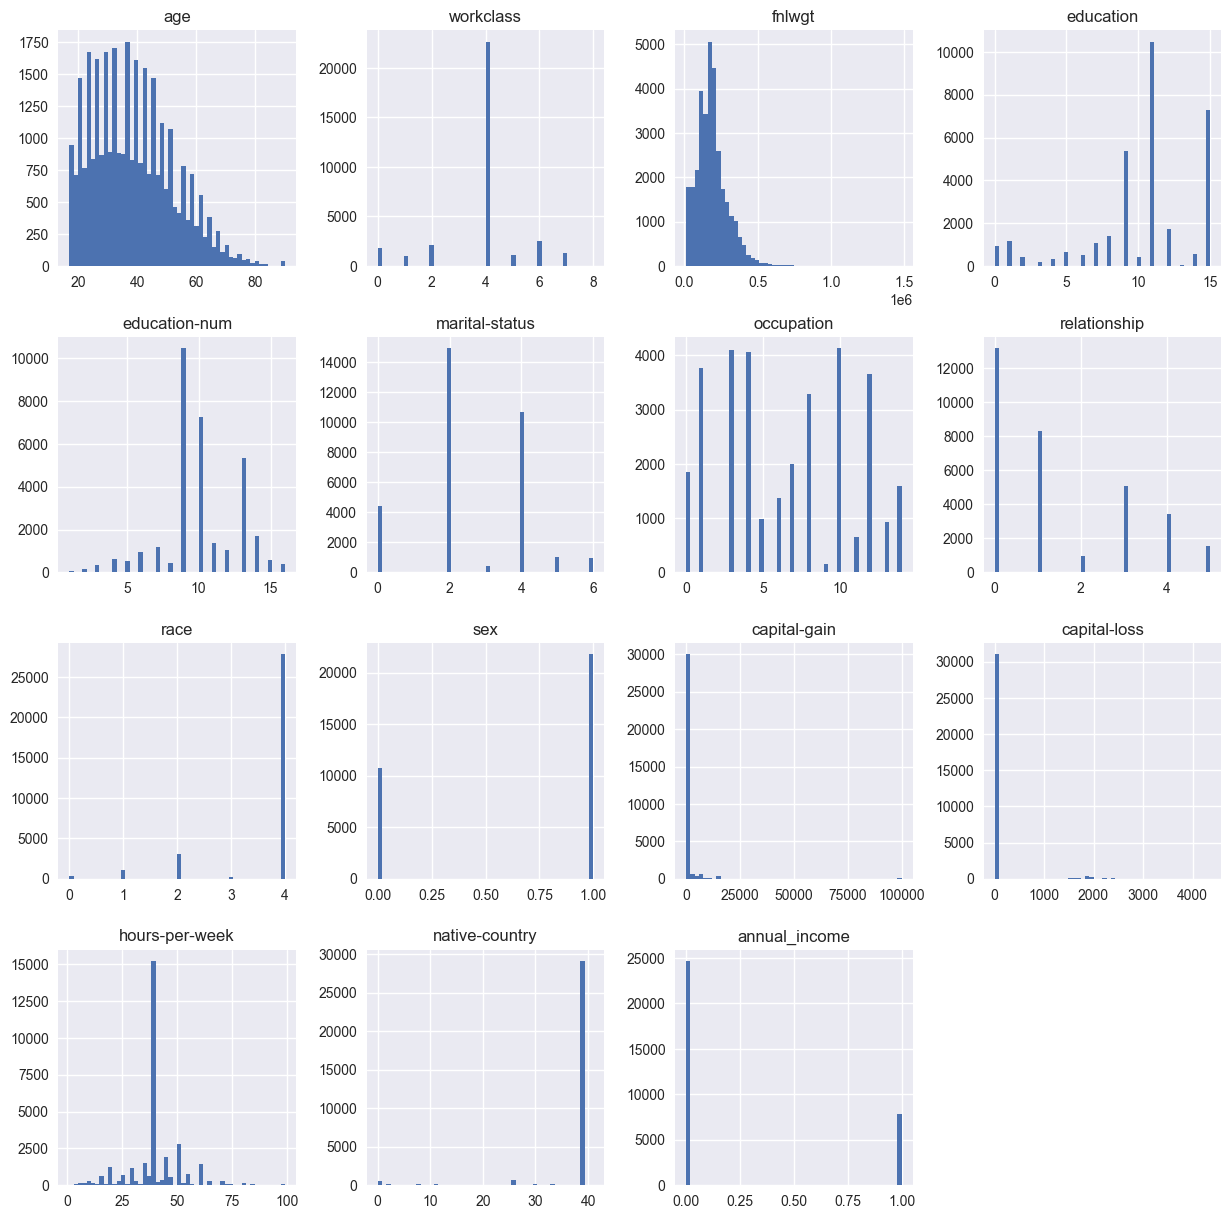

In [14]:
plt.style.use("seaborn-v0_8")
df.hist(bins=50, figsize=(15,15))
plt.show()

<Axes: >

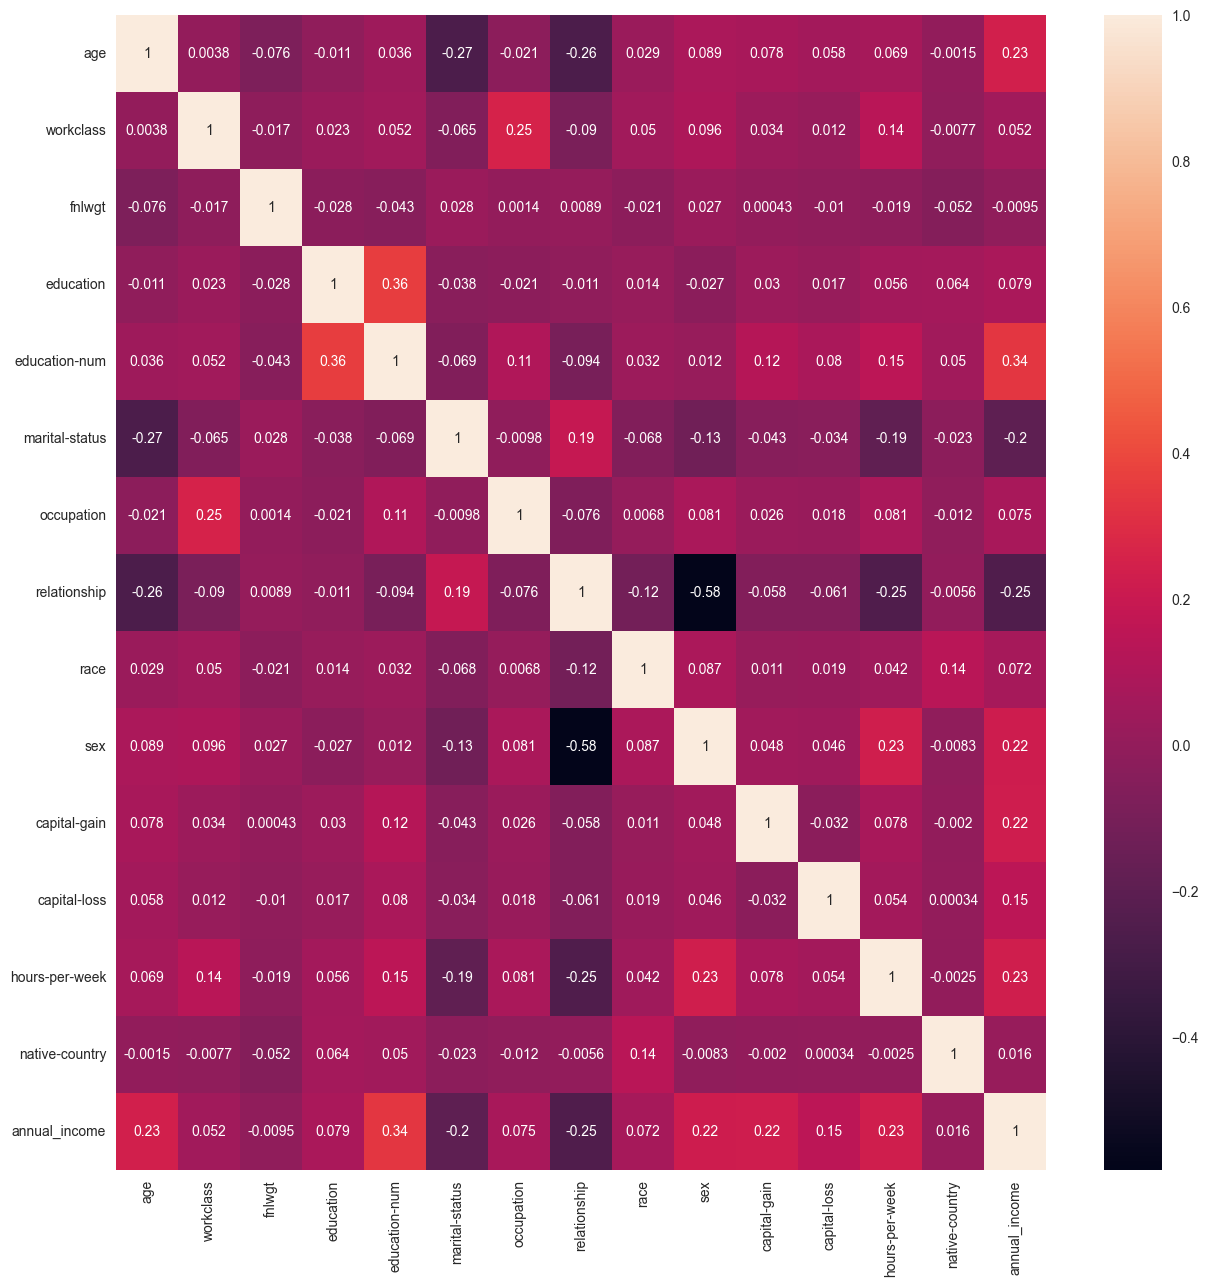

In [15]:
plt.figure(figsize=(15,15))
sns.heatmap(df.corr(),annot=True)

In [16]:
df[~df['annual_income'].isin([1,0]) ]

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,annual_income


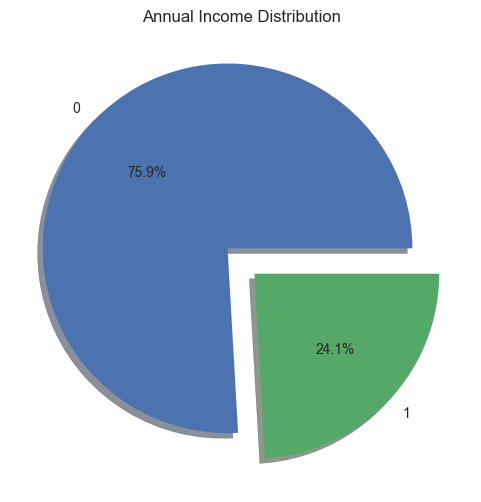

In [17]:

i = df['annual_income'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    i,
    labels=i.index,
    autopct="%1.1f%%",
    explode=[0.1, 0.1],  # separate slices slightly
    shadow=True
)

plt.title("Annual Income Distribution")
plt.show()

In [18]:
df.columns


Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country',
       'annual_income'],
      dtype='object')

In [19]:
x= df.drop(['annual_income'], axis=1)
y= df['annual_income']
print(x.shape)
print(y.shape)

(32537, 14)
(32537,)


In [20]:
x_train, x_test, y_train, y_test= train_test_split(x,y, test_size=0.2, random_state=25)
print(x_train.shape)
print(x_test.shape)


(26029, 14)
(6508, 14)


In [21]:
x

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,39,7,77516,9,13,4,1,1,4,1,2174,0,40,39
1,50,6,83311,9,13,2,4,0,4,1,0,0,13,39
2,38,4,215646,11,9,0,6,1,4,1,0,0,40,39
3,53,4,234721,1,7,2,6,0,2,1,0,0,40,39
4,28,4,338409,9,13,2,10,5,2,0,0,0,40,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,27,4,257302,7,12,2,13,5,4,0,0,0,38,39
32557,40,4,154374,11,9,2,7,0,4,1,0,0,40,39
32558,58,4,151910,11,9,6,1,4,4,0,0,0,40,39
32559,22,4,201490,11,9,4,1,3,4,1,0,0,20,39


In [22]:
cat_cols

['workclass',
 'education',
 'marital-status',
 'occupation',
 'relationship',
 'race',
 'sex',
 'native-country',
 'annual_income']

In [23]:
x.columns

Index(['age', 'workclass', 'fnlwgt', 'education', 'education-num',
       'marital-status', 'occupation', 'relationship', 'race', 'sex',
       'capital-gain', 'capital-loss', 'hours-per-week', 'native-country'],
      dtype='object')

In [24]:
x_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
18860,30,4,509500,9,13,4,13,1,4,0,4787,0,45,39
8883,41,6,200574,14,15,2,10,0,4,1,0,1977,60,39
16527,46,5,326048,15,10,2,4,0,4,1,0,0,40,39
8039,46,5,182655,8,11,2,4,0,4,1,0,0,60,39
1694,44,4,151504,15,10,2,12,0,4,1,0,0,50,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32084,48,4,105808,6,5,6,14,4,4,1,0,0,40,39
26784,28,4,68642,11,9,4,8,1,4,0,0,0,46,39
6620,26,4,289980,4,3,2,5,0,4,1,0,0,30,26
24909,32,4,232855,11,9,4,7,4,2,0,0,0,40,39


In [26]:
num_cols=["age","fnlwgt",  "education-num", 'capital-gain', 'capital-loss', 'hours-per-week']
scaler= StandardScaler()

x_train[num_cols]= scaler.fit_transform(x_train[num_cols])
x_test[num_cols]= scaler.transform(x_test[num_cols])
    

In [27]:
x_train

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
18860,-0.628877,4,3.026097,9,1.135897,4,13,1,4,0,0.478115,-0.217798,0.368040,39
8883,0.175711,6,0.102393,14,1.914602,2,10,0,4,1,-0.146829,4.658072,1.583606,39
16527,0.541432,5,1.289890,15,-0.032161,2,4,0,4,1,-0.146829,-0.217798,-0.037149,39
8039,0.541432,5,-0.067194,8,0.357192,2,4,0,4,1,-0.146829,-0.217798,1.583606,39
1694,0.395144,4,-0.362010,15,-0.032161,2,12,0,4,1,-0.146829,-0.217798,0.773229,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32084,0.687721,4,-0.794481,6,-1.978924,6,14,4,4,1,-0.146829,-0.217798,-0.037149,39
26784,-0.775166,4,-1.146224,11,-0.421513,4,8,1,4,0,-0.146829,-0.217798,0.449078,39
6620,-0.921455,4,0.948539,4,-2.757629,2,5,0,4,1,-0.146829,-0.217798,-0.847526,26
24909,-0.482589,4,0.407903,11,-0.421513,4,7,4,2,0,-0.146829,-0.217798,-0.037149,39


In [28]:
x_test

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
10055,0.029422,7,-0.354411,9,1.135897,2,10,0,4,1,-0.146829,-0.217798,-0.037149,39
15113,-0.263156,4,-1.279166,0,-1.589571,6,8,1,2,0,-0.146829,4.665471,-0.037149,39
25522,2.004319,0,-0.771985,6,-1.978924,2,0,0,2,1,-0.146829,-0.217798,-0.037149,39
28942,-0.116867,4,0.947650,15,-0.032161,4,8,2,1,1,-0.146829,-0.217798,-0.847526,40
10490,0.541432,4,1.941133,11,-0.421513,2,8,0,4,1,-0.146829,-0.217798,-0.037149,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26392,-0.409444,4,-0.547223,11,-0.421513,0,4,1,4,0,-0.146829,-0.217798,0.368040,39
1822,-1.433465,4,2.163199,15,-0.032161,4,12,3,4,1,-0.146829,-0.217798,-0.361300,39
603,0.248855,2,-0.133263,6,-1.978924,2,8,0,4,1,-0.146829,-0.217798,-0.037149,39
18962,0.029422,4,-1.567717,15,-0.032161,2,12,0,4,1,-0.146829,-0.217798,-0.037149,30


In [30]:
logistic_reg= LogisticRegression()
logistic_reg.fit(x_train,y_train)
y_pred= logistic_reg.predict(x_test)


accuracy= accuracy_score(y_test, y_pred)
cm= confusion_matrix(y_pred, y_test)
report= classification_report(y_pred, y_test)

print(f"accuracy: {accuracy}")
print(cm)
print(f"Classification_report: {report}")


accuracy: 0.8292870313460357
[[4687  825]
 [ 286  710]]
Classification_report:               precision    recall  f1-score   support

           0       0.94      0.85      0.89      5512
           1       0.46      0.71      0.56       996

    accuracy                           0.83      6508
   macro avg       0.70      0.78      0.73      6508
weighted avg       0.87      0.83      0.84      6508



C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
